In [1]:
import os
import shutil
from pathlib import Path

import pyvista as pv
import ogstools as ot
import ogstools.variables as ov

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from meshing import create_cube_mesh_p, create_cube_mesh_psc
from functions import pwd_ps,step_rate_s, scale_and_smooth, pickings

# Path

In [2]:
OGS_PATH = None

if OGS_PATH is not None:
    os.environ["OGS_BIN_PATH"] = OGS_PATH
OUT_DIR = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out"))
MESH_DIR = OUT_DIR / "mesh"
shutil.rmtree(OUT_DIR, ignore_errors=True)
MESH_DIR.mkdir(parents=True, exist_ok=True)

# Point-source and model performance

## Point-source analytical

In [26]:

k=5.35e-9
q=0.00016 #positive for production
r=np.linspace(1,25,20) #array or r 
t=np.linspace(0,100,26) #  t have to be equivalent to ms.timevalues 
t[0]=1e-10
rgeo=np.geomspace(1, 25, 6).round(2)

ddict={"p_i":0,
       "mu":1e-3 ,
       "B":1,
       "por":0.2,
       "c_t":4.37e-5 ,
       "r_w":0.038,
      }

rinv=np.sqrt(k*max(t)/(ddict['por']*ddict['mu']*ddict['c_t']))
print("Investigation radius (m): ",f"{rinv:.2f}",'\n','"unperturbed" threshold (m): ', f"{4*rinv:.2f}")

Investigation radius (m):  7.82 
 "unperturbed" threshold (m):  31.30


In [27]:
#Point source
r_col=rgeo
pi, mu, B,rw= ddict['p_i'], ddict['mu'], ddict['B'],ddict['r_w']

C_vec = (mu * B) / (4 * np.pi * k * rw)
term1_matrix = pwd_ps(t, ddict, k, r_col) 

p_wsr = pi - (C_vec * q * term1_matrix)

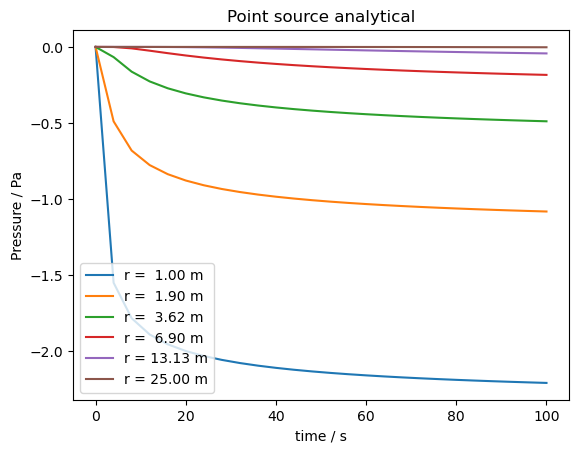

In [28]:
line_labels = [f"r = {val:>5.2f} m" for val in rgeo]

fig0, ax=plt.subplots()
ax.plot(t, p_wsr,label=line_labels) 

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / Pa")
plt.title("Point source analytical")

plt.legend()
plt.pause(1)

## Point-source numerical

### Meshing 3D point-source

In [29]:
cube_file = MESH_DIR / "cube_3d_ps.msh"

create_cube_mesh_p(
        cube_file,        
        width=50.0,
        height=50.0,
        thickness=50.0,
        mesh_size=2.0, #optimal one-size-to-mesh ratio= 20-40, ie, side(50)/mesh_size(2)=25
        center_z=-100.0,
        debug_gui= False,
        local_ref=True,
    )

cube_meshes = ot.meshes_from_gmsh(cube_file, log=False)
for name, mesh in cube_meshes.items():
    vtu = MESH_DIR / f"cube_{name}.vtu"
    pv.save_meshio(vtu, mesh)
    print(f"Saved {vtu}")


Saved _out\mesh\cube_domain.vtu
Saved _out\mesh\cube_physical_group_points.vtu
Saved _out\mesh\cube_physical_group_center.vtu
Saved _out\mesh\cube_physical_group_edges.vtu
Saved _out\mesh\cube_physical_group_bottom.vtu
Saved _out\mesh\cube_physical_group_top.vtu
Saved _out\mesh\cube_physical_group_back.vtu
Saved _out\mesh\cube_physical_group_front.vtu
Saved _out\mesh\cube_physical_group_left.vtu
Saved _out\mesh\cube_physical_group_right.vtu
Saved _out\mesh\cube_physical_group_volume.vtu


### PRJ file pre-procesing

In [30]:
PROJECT_BASENAME = "Point_source_3Dtest" 
prj_in = Path(f"{PROJECT_BASENAME}.prj")
prj_out = OUT_DIR / f"{PROJECT_BASENAME}_updated.prj"

prj = ot.Project(input_file=prj_in, output_file=prj_out)

In [31]:
parent_xpath = "./processes/process[1]"
target_path = "./processes/process[1]/equation_balance_type"

try:
    root = prj.tree.getroot()
    node = root.find(target_path)
    
    if node is not None:
        if node.text == "volume":
            print("Verified: equation_balance_type 'volume' already exists.")
        else:
            prj.replace_text("volume", xpath=target_path)
            print("Updated: Existing equation_balance_type changed to 'volume'.")
    else:
        print("Adding equation_balance_type=volume")
        prj.add_element(
            parent_xpath=parent_xpath, 
            tag="equation_balance_type", 
            text="volume"
        )

except Exception as e:
    print(f"Error: {e}")

Adding equation_balance_type=volume


In [32]:
#permeability ref numerical
k_ref= 5.35e-9

In [33]:
q=-1*q #changing to proudction OGS

try:
    prj.replace_parameter_value(name="p0", value=ddict["p_i"])
    prj.replace_parameter_value(name="pi_inf", value=ddict["p_i"])
    prj.replace_parameter_value(name="q_in", value=q)

    mid=0
    prj.replace_phase_property_value(mediumid=mid, phase="AqueousLiquid", name="viscosity", value=ddict["mu"])
    
    prj.replace_medium_property_value(mediumid=mid, name="porosity", value=ddict["por"])
    prj.replace_medium_property_value(mediumid=mid, name="permeability", value=k_ref)
    prj.replace_medium_property_value(mediumid=mid, name="storage", value=ddict["c_t"])
    
    print("media/properties, Parameters updated")
except Exception as e:
    print(f"Error occurred: {e}")
    
prj.write_input()
print('\n', f"prj update in {prj_out} as {PROJECT_BASENAME}_updated.prj")

media/properties, Parameters updated

 prj update in _out\Point_source_3Dtest_updated.prj as Point_source_3Dtest_updated.prj


### Running OGS 

In [34]:
!ogs ./_out/Point_source_3Dtest_updated.prj -m ./_out/mesh -o ./_out/

info: This is OpenGeoSys-6 version 6.5.5.
info: OGS started on 2026-03-04 16:45:14+0100.
info: Eigen use 16 threads
info: Reading project file _out\Point_source_3Dtest_updated.prj.
info: readRasters ...
info: readRasters done
info: ConstantParameter: p0
info: ConstantParameter: pi_inf
info: ConstantParameter: constant_porosity_parameter
info: ConstantParameter: q_in
info: Initialize processes.
info: Time step #0 started. Time: 0. Step size: 0.
info: [time] Output of timestep 0 took 0.297873 s.
info: Time step #0 took 0.333603 s.
info: OpenGeoSys is now initialized.
info: OGS started on 2026-03-04 16:45:16+0100.
info: Solve processes.
info: Time step #1 started. Time: 2. Step size: 2.
info: Solving process #0 started.
info: Iteration #1 started.
info: [time] Assembly took 0.331826 s.
info: [time] Applying Dirichlet BCs took 0.0093915 s.
info: ------------------------------------------------------------------
info: *** Eigen solver compute()
info: -> compute with Eigen iterative linear s

## Results and visualization

### Post-processing 

In [37]:
pvd_path = Path("_out/liquid_ps3d_test.pvd")
ms = ot.MeshSeries(pvd_path)
pressure=ot.variables.pressure
pressure= pressure.replace(output_unit="Pa")

In [38]:
y=25
z=-100

#coords=np.array(np.geomspace([26,y,z],[50,y,z],6).round(2)) #extracting along x geometrically
coords=np.array(np.linspace([26,y,z],[50,y,z],6)) #extracting along x linearly
coords[:,0]=rgeo+25 #adjusting geometry shifting
ms_probes = ms.extract_probe(ms,points=coords)

labels = [f"x={pt[0]:>5.1f}, y={y}, z={z}" for pt in coords]

diff = p_wsr - ms_probes['pressure']



100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:01<00:00, 17.03it/s]


### Performance comparison

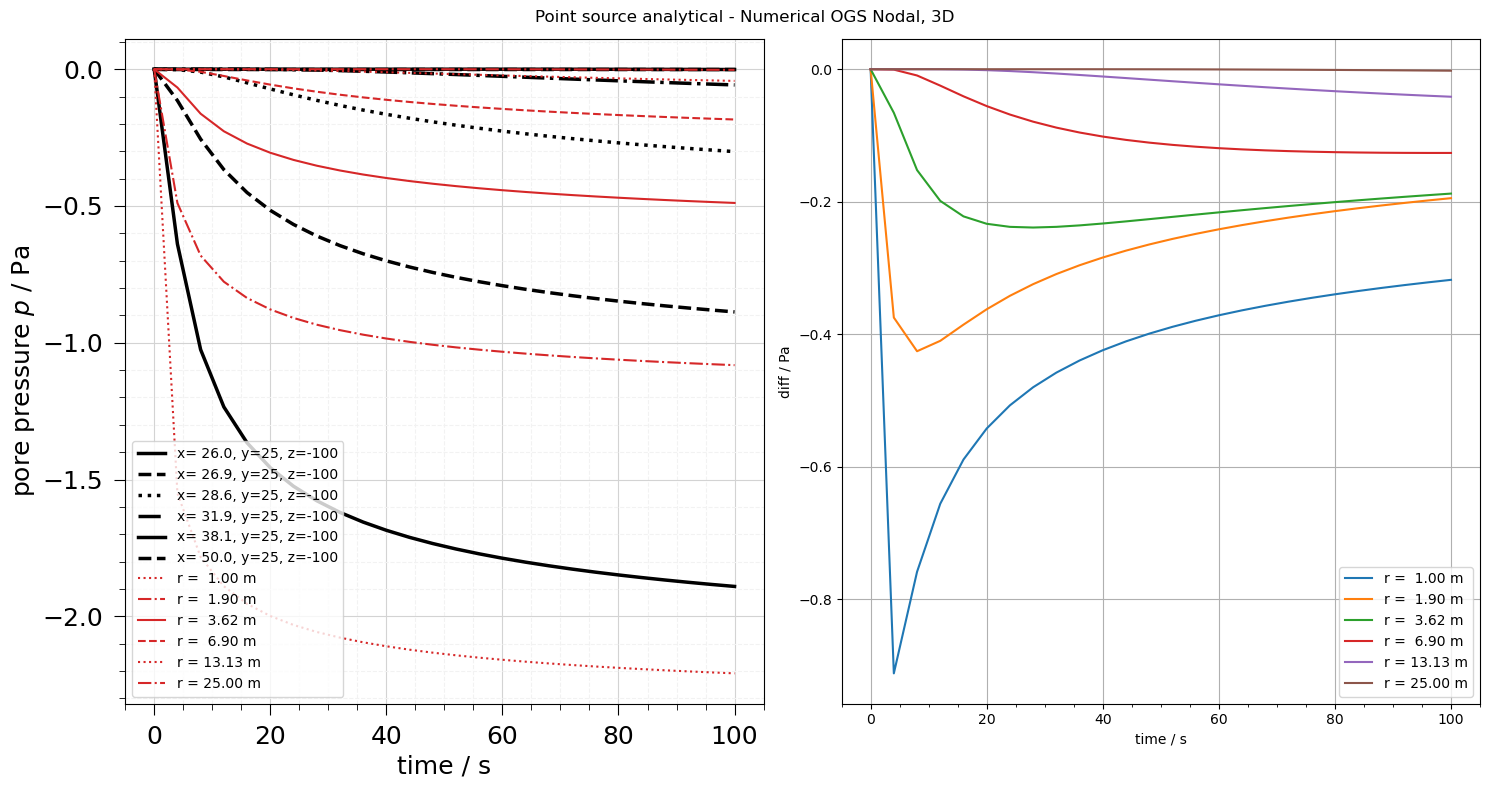

In [40]:
fig, axs= plt.subplots(nrows=1, ncols=2,figsize=[15,8], sharex=True)
ot.plot.line(ms_probes,"time", pressure,ax=axs[0], color='k',fontsize=18,label=labels)
axs[0].plot(t, p_wsr,color='tab:red', label=line_labels) 
axs[1].plot(t, diff, label=line_labels)

fig.suptitle("Point source analytical - Numerical OGS Nodal, 3D")
axs[1].set_xlabel("time / s")
axs[1].set_ylabel("diff / Pa")

axs[0].legend()
axs[1].legend()
axs[1].grid()
plt.tight_layout()

# plt.savefig("psn_3D_BM.pdf", format="pdf")  
plt.show()

# STIMTEC Example

## Path adjoint

In [41]:
OGS_PATH = None

if OGS_PATH is not None:
    os.environ["OGS_BIN_PATH"] = OGS_PATH
OUT_DIR = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out_ps"))
MESH_DIR = OUT_DIR / "mesh"
shutil.rmtree(OUT_DIR, ignore_errors=True)
MESH_DIR.mkdir(parents=True, exist_ok=True)

## Point-source step-rate

### Preprocesing and preparing data

In [42]:
cwd=Path.cwd()
newpath=cwd/"STIMTEC_example"
dataex=pd.read_csv(newpath/"BH10_20180716_51.6.csv",sep=",",header=0)


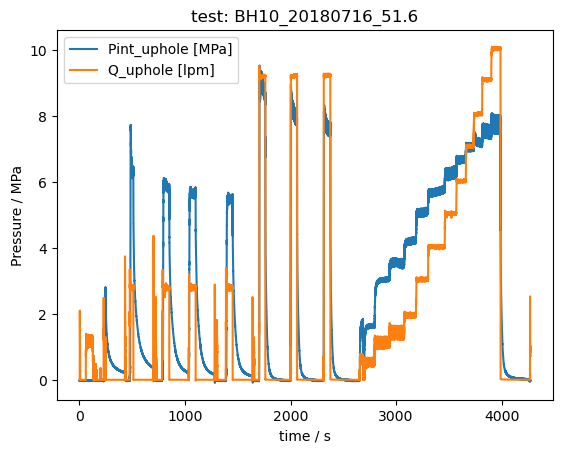

In [43]:
#visualising full data set
fig1, ax=plt.subplots()

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa")
plt.title("test: BH10_20180716_51.6")

ax.plot(dataex['Zeit [s]'],dataex['Pint_uphole [MPa]'],label="Pint_uphole [MPa]")
ax.plot(dataex['Zeit [s]'],dataex['Q_uphole [lpm]'],label="Q_uphole [lpm]")

plt.legend()
plt.show()

steps 	 15


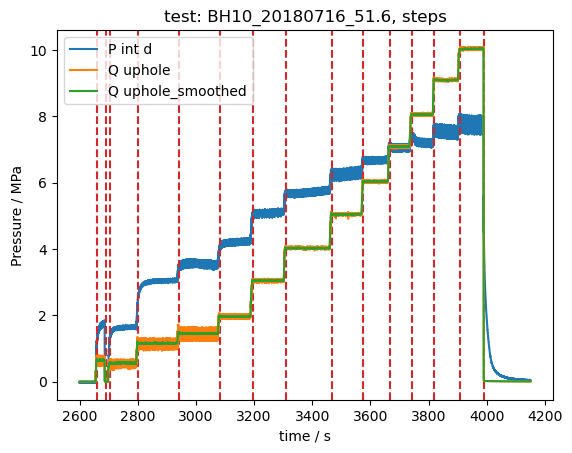

In [44]:
#isolating Step-rate and preparing curve

mask = (dataex['Zeit [s]'] > 2600) & (dataex['Zeit [s]'] < 4150)
dataex_f = dataex.loc[mask, :].copy()
dataex_f = dataex_f.reset_index(drop=True)

dataex_f['Q_uphole [lpm]_s']=scale_and_smooth(dataex_f['Q_uphole [lpm]'])

steps_=pickings(dataex_f['Q_uphole [lpm]_s'],60,20)
print('steps','\t', len(steps_))

fig1, ax=plt.subplots()

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa")
plt.title("test: BH10_20180716_51.6, steps")

ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_uphole [MPa]'],label="P int d")
for i in range (len(steps_)):
     ax.axvline(x=dataex_f.loc[steps_[i,0],'Zeit [s]'],ls="--",color="tab:red")
ax.plot(dataex_f['Zeit [s]'],dataex_f['Q_uphole [lpm]'],label="Q uphole")
ax.plot(dataex_f['Zeit [s]'],dataex_f['Q_uphole [lpm]_s'],label="Q uphole_smoothed")

plt.legend()
plt.show()

In [45]:
#protocol
pr=pd.DataFrame(data=steps_,
                      index = np.arange(len(steps_)),
                      columns=['index','qs'])
protocol={'index':0,'qs':dataex_f['Q_uphole [lpm]_s'].values[0],'T_s':dataex_f['Zeit [s]'].values[0]}
pr["T_s"]=dataex_f.loc[steps_[:,0].astype(int),'Zeit [s]'].values
protocol=pd.concat([pd.DataFrame(protocol,index=[0]),pr],axis=0)
protocol.reset_index(drop=True, inplace=True)
protocol['qs']=-protocol['qs']/60000 #injection is negative flow


In [119]:
#data 
ddict={"p_i":0,
       "mu":1e-3 ,
       "B":1,
       "por":0.030,
       "c_t":4e-6 ,
       "r_w":0.038 
      }

### Point-source analytical running

In [120]:
delta_t=dataex_f['Zeit [s]'].values
tp=protocol['T_s'].values
q_array=protocol['qs'].values

r_val=ddict['r_w'] #at wellbore face
k_val = np.geomspace(2e-14, 5e-14, 5) #real wellbore

pwsr2= step_rate_s(pwd_ps, delta_t, tp, q_array, ddict, k_val, r_val)

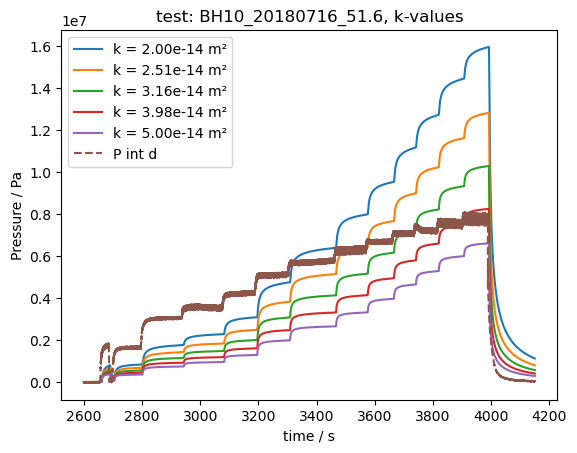

In [121]:
fig2, ax=plt.subplots()

for i, k in enumerate(k_val):
    ax.plot(delta_t, pwsr2[:, i], label=f'k = {k:.2e} m²')
    
ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_uphole [MPa]']*1e6,label="P int d", ls="--")

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / Pa")
plt.title("test: BH10_20180716_51.6, k-values")

plt.legend()
plt.pause(1)

In [122]:
k_val=4.5e-14 #reference k

rgeo=np.geomspace(0.038,5,5)
r_val=rgeo
pwsr2= step_rate_s(pwd_ps, delta_t, tp, q_array, ddict, k_val, r_val)

rinv=np.sqrt(k_val*(max(dataex_f['Zeit [s]'])-min(dataex_f['Zeit [s]']))/(ddict['por']*ddict['mu']*ddict['c_t']))
print("Investigation radius (m): ",f"{rinv:.2f}",'\n','"unperturbed" threshold (m): ', f"{4*rinv:.2f}")

Investigation radius (m):  0.76 
 "unperturbed" threshold (m):  3.05


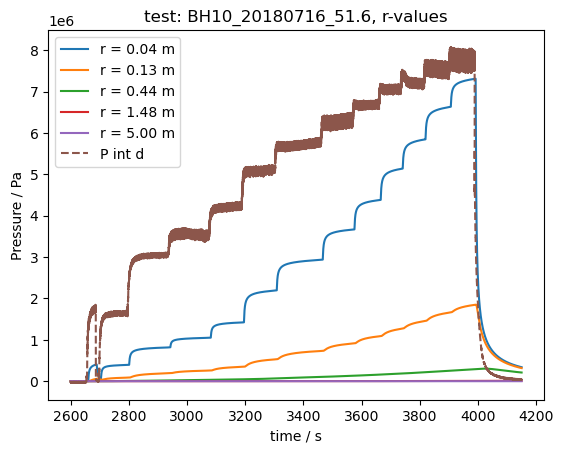

In [123]:
line_labels = [f"r = {val:>5.2f} m" for val in rgeo]

fig3, ax=plt.subplots()

for i, r in enumerate(rgeo):
    plt.plot(delta_t, pwsr2[:, i], label=f'r = {r:.2f} m')
ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_uphole [MPa]']*1e6,label="P int d", ls="--")

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / Pa")
plt.title("test: BH10_20180716_51.6, r-values")

plt.legend()
plt.pause(1)

## Point-source Numerical

### Meshing 3D point-source

In [69]:
cube_file = MESH_DIR / "cube_3d_ps.msh"

create_cube_mesh_psc(
        cube_file,        
        width=400.0,
        height=400.0,
        thickness=400.0,
        mesh_size=20, #optimal one-size-to-mesh ratio= 20-40, ie, side(50)/mesh_size(2)=25
        target_rw=1, #minum possible in current setting 0.7
        center_z=-500.0,
        debug_gui= False,
        local_ref=True,
    )

cube_meshes = ot.meshes_from_gmsh(cube_file, log=False)
for name, mesh in cube_meshes.items():
    vtu = MESH_DIR / f"cube_{name}.vtu"
    pv.save_meshio(vtu, mesh)
    print(f"Saved {vtu}")


Saved _out_ps\mesh\cube_domain.vtu
Saved _out_ps\mesh\cube_physical_group_points.vtu
Saved _out_ps\mesh\cube_physical_group_center.vtu
Saved _out_ps\mesh\cube_physical_group_edges.vtu
Saved _out_ps\mesh\cube_physical_group_bottom.vtu
Saved _out_ps\mesh\cube_physical_group_top.vtu
Saved _out_ps\mesh\cube_physical_group_back.vtu
Saved _out_ps\mesh\cube_physical_group_front.vtu
Saved _out_ps\mesh\cube_physical_group_left.vtu
Saved _out_ps\mesh\cube_physical_group_right.vtu
Saved _out_ps\mesh\cube_physical_group_volume.vtu


### PRJ file pre-procesing

In [197]:
#adjusting to
ddict={"p_i":0,
       "mu":1e-3 ,
       "B":1,
       "por":0.030,
       "c_t":4e-6 ,
       "r_w":0.038 
      }

In [193]:
rnode=0.7


In [198]:
#Permeability reference and pressure pi, pinf

k_ref=4.5e-14*ddict['r_w']/rnode
ddict['c_t']=ddict['c_t']*ddict['r_w']/rnode
p_inf=0
p0=0

In [200]:
PROJECT_BASENAME = "Point_source_3Dtest" 
TESTSR= "BH10_20180716_51.6"
prj_in = Path(f"{PROJECT_BASENAME}.prj")
prj_out = OUT_DIR / f"{TESTSR}_PS3D.prj"

prj = ot.Project(input_file=prj_in, output_file=prj_out)

In [201]:
parent_xpath = "./processes/process[1]"
target_path = "./processes/process[1]/equation_balance_type"

try:
    root = prj.tree.getroot()
    node = root.find(target_path)
    
    if node is not None:
        if node.text == "volume":
            print("Verified: equation_balance_type 'volume' already exists.")
        else:
            prj.replace_text("volume", xpath=target_path)
            print("Updated: Existing equation_balance_type changed to 'volume'.")
    else:
        print("Adding equation_balance_type=volume")
        prj.add_element(
            parent_xpath=parent_xpath, 
            tag="equation_balance_type", 
            text="volume"
        )

except Exception as e:
    print(f"Error: {e}")

Adding equation_balance_type=volume


In [202]:
last_t=dataex_f.loc[dataex_f.tail(1).index.values.astype(int),'Zeit [s]':'Q_uphole [lpm]']
last_t['Q_uphole [lpm]']=last_t['Q_uphole [lpm]']/60000
last_t=last_t.values.flatten().tolist() 
print(last_t)

param_name = "q_in" #inlet flow

def create_sr_ogs(T,q,data,var="t"):
    q=-q
    q_list=q.tolist()
    q_list.append(data[1])
    
    T_list= T.tolist()
    T_list.append(data[0])
        
    parts = [f"{var} < {T_list[i+1]:g} ? {q_list[i]:.6g} :" for i in range(0, len(T_list)-1)]
    
    return "(" + "\n           ".join(parts) + f"\n           {q_list[-1]:.6g})",T_list


try:
    prj.replace_parameter_value(name="p0", value=p0)
    prj.replace_parameter_value(name="pi_inf", value=p_inf)
    
    root = prj.tree.getroot() # Access the underlying ElementTree
    param_node = root.find(f".//parameters/parameter[name='{param_name}']")
    value_tag = param_node.find("value")
    if value_tag is not None:
         param_node.remove(value_tag)
    
    n_type = prj.replace_text(
        "Function", xpath=f".//parameters/parameter[name='{param_name}']/type"
    )
    
    n_expr,Times = create_sr_ogs(tp,q_array,last_t)
    
    prj.add_element(
        parent_xpath=f".//parameters/parameter[name='{param_name}']", 
        tag="expression", 
        text=n_expr
    )
    
    print("flow_expression", n_expr)
    
    #timestepping calculations 
    delta_res=5
    prj.replace_text(Times[0], 
                     xpath="./time_loop/processes/process/time_stepping/t_initial")
    prj.replace_text(Times[-1],
                     xpath="./time_loop/processes/process/time_stepping/t_end")
    prj.replace_text("1",
                     xpath="./time_loop/processes/process/time_stepping/timesteps/pair/repeat")
    prj.replace_text(delta_res, #resolution of stepping
        xpath="./time_loop/processes/process/time_stepping/timesteps/pair/delta_t")
    
    print("delta_t calculation: ", delta_res)

    #out and suffix
    outsteps=delta_res #10 at convenience
    prefix= TESTSR
    
    prj.replace_text("1",
                     xpath="./time_loop/output/timesteps/pair/repeat")
    prj.replace_text(outsteps, #resolution of stepping
                    xpath="./time_loop/output/timesteps/pair/each_steps")
    prj.replace_text(prefix, #resolution of stepping
                     xpath="./time_loop/output/prefix")
    
    print("ouput_res: ", outsteps,'\n','prefix:',prefix )
    
    mid=0
    prj.replace_phase_property_value(mediumid=mid, phase="AqueousLiquid", name="viscosity", value=ddict["mu"])
    
    prj.replace_medium_property_value(mediumid=mid, name="porosity", value=ddict["por"])
    prj.replace_medium_property_value(mediumid=mid, name="permeability", value=k_ref)
    prj.replace_medium_property_value(mediumid=mid, name="storage", value=ddict["c_t"])
    
    print("media/properties, Parameters updated")
    
except Exception as e:
    
    print(f"Error occurred: {e}")

prj.write_input()
print('\n', f"prj update in {prj_in} as {prj_out}")

[4149.973, 5.675e-08]
flow_expression (t < 2659.97 ? 2.2339e-08 :
           t < 2689.27 ? 1.08984e-05 :
           t < 2703.72 ? -5.02127e-09 :
           t < 2800.72 ? 9.38908e-06 :
           t < 2942.27 ? 1.90956e-05 :
           t < 3081.27 ? 2.41941e-05 :
           t < 3195.37 ? 3.27881e-05 :
           t < 3308.12 ? 5.0799e-05 :
           t < 3466.22 ? 6.72243e-05 :
           t < 3575.17 ? 8.41117e-05 :
           t < 3665.42 ? 0.000100544 :
           t < 3741.02 ? 0.000118131 :
           t < 3819.37 ? 0.000134109 :
           t < 3906.42 ? 0.000151677 :
           t < 3991.77 ? 0.000166767 :
           t < 4149.97 ? 2.89914e-07 :
           5.675e-08)
delta_t calculation:  5
ouput_res:  5 
 prefix: BH10_20180716_51.6
media/properties, Parameters updated

 prj update in Point_source_3Dtest.prj as _out_ps\BH10_20180716_51.6_PS3D.prj


### Running OGS

In [203]:
!ogs _out_ps\BH10_20180716_51.6_PS3D.prj -m ./_out_ps/mesh -o ./_out_ps/

info: This is OpenGeoSys-6 version 6.5.5.
info: OGS started on 2026-03-04 22:54:41+0100.
info: Eigen use 16 threads
info: Reading project file _out_ps\BH10_20180716_51.6_PS3D.prj.
info: readRasters ...
info: readRasters done
info: ConstantParameter: p0
info: ConstantParameter: pi_inf
info: ConstantParameter: constant_porosity_parameter
info: FunctionParameter: q_in
info: Initialize processes.
info: Time step #0 started. Time: 2600.023. Step size: 0.
info: [time] Output of timestep 0 took 0.306025 s.
info: Time step #0 took 0.344803 s.
info: OpenGeoSys is now initialized.
info: OGS started on 2026-03-04 22:54:43+0100.
info: Solve processes.
info: Time step #1 started. Time: 2605.0230000000001. Step size: 5.
info: Solving process #0 started.
info: Iteration #1 started.
info: [time] Assembly took 0.257566 s.
info: [time] Applying Dirichlet BCs took 0.0075534 s.
info: ------------------------------------------------------------------
info: *** Eigen solver compute()
info: -> compute with E

## Results and visualization

### Post-processing 

In [204]:
pvd_path = Path("_out_ps/BH10_20180716_51.6.pvd")
ms = ot.MeshSeries(pvd_path)
pressure=ot.variables.pressure
pressure= pressure.replace(output_unit="Pa")

In [208]:
y=200
z=-500

np.geomspace(0.038,5,5)

coords=np.array(np.linspace([200.038,y,z],[205,y,z],5)) #extracting along x linearly
coords[:,0]=rgeo+200 #adjusting geometry shifting
ms_probes = ms.extract_probe(ms,points=coords)

labels = [f"x={pt[0]:>5.1f}, y={y}, z={z}" for pt in coords]

# diff = pwsr2 - ms_probes['pressure']

### Analytical and Numerical OGS comparison

C:\Users\acer\AppData\Local\Temp\ipykernel_24668\1573124153.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


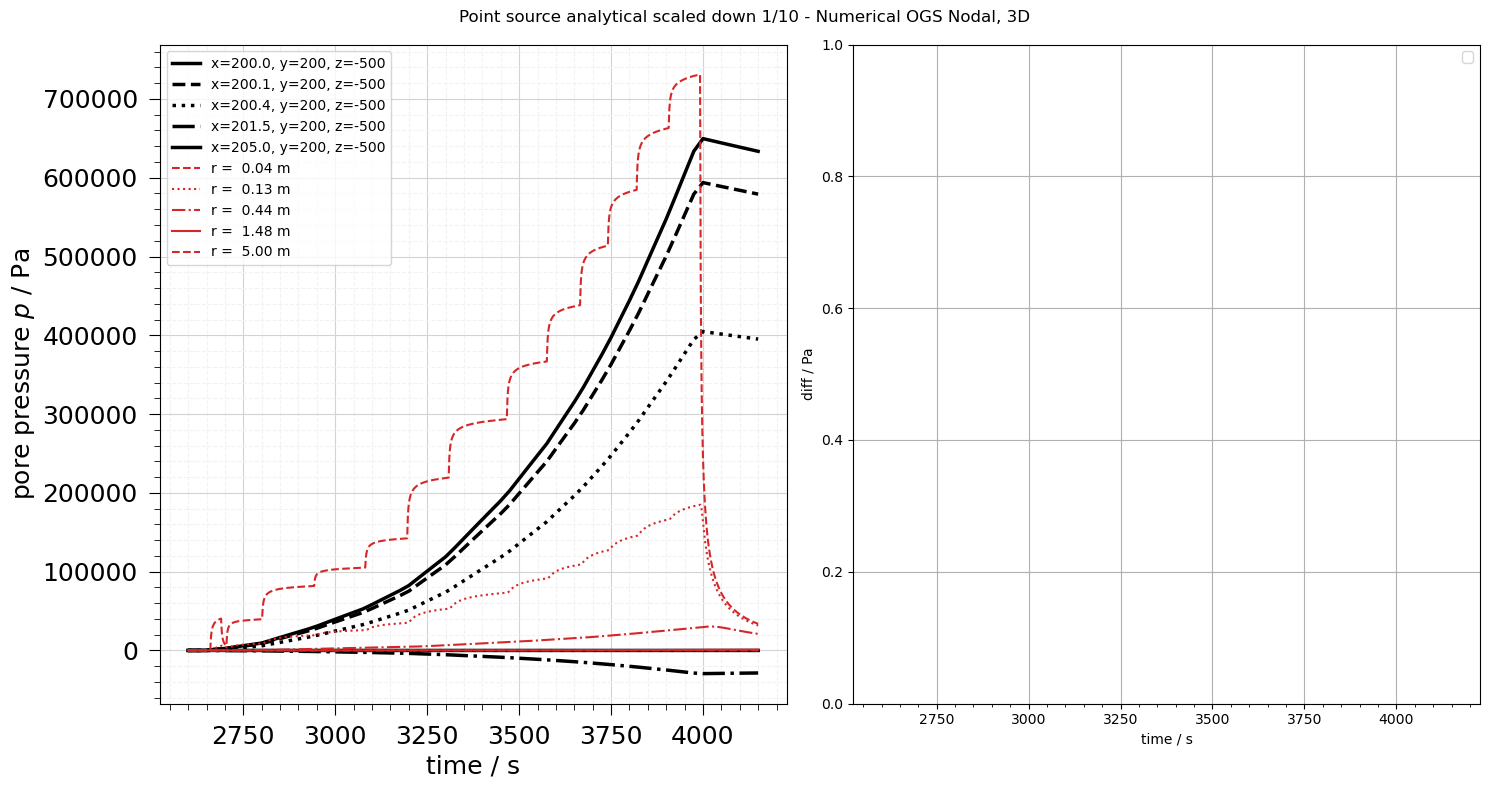

In [209]:
t=dataex_f['Zeit [s]']

fig4, axs= plt.subplots(nrows=1, ncols=2,figsize=[15,8], sharex=True)
ot.plot.line(ms_probes,"time", pressure,ax=axs[0], color='k',fontsize=18,label=labels)
axs[0].plot(t, pwsr2/10,color='tab:red', label=line_labels) 
# axs[1].plot(t, diffMpa, label=line_labels)

# fig4.suptitle("Point source analytical - Numerical OGS Nodal, 3D")
fig4.suptitle("Point source analytical scaled down 1/10 - Numerical OGS Nodal, 3D") 
axs[1].set_xlabel("time / s")
axs[1].set_ylabel("diff / Pa")

axs[0].legend()
axs[1].legend()
axs[1].grid()
plt.tight_layout()

plt.show()

**NOTE: Numerical difference is 10 times with current setting/configuration** Scaling should be done node/rw